In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import scipy.io as io
import argparse

import src.models.models as models
import src.training.self_supervision as ssl
import src.utils.utils as utils
import src.utils.extractor as extractor

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may hav

198


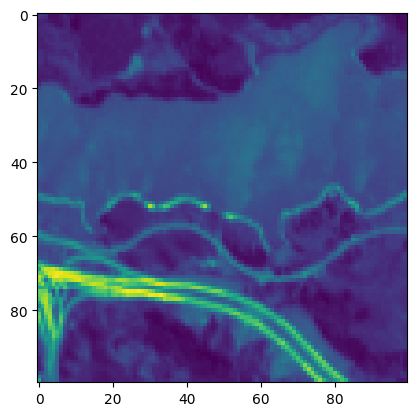

In [2]:
dataset = "jasper"
data = io.loadmat(f"datasets/{dataset}.mat")
Y = torch.tensor(data["Y"])
Y = Y.to(torch.float32)
E = torch.tensor(data["E"])
B, c, N = E.shape[0], E.shape[1], Y.shape[1]
print(B)

Y_flat, H = utils.oneD_to_2d(Y)
W = H

plt.imshow(Y_flat.cpu()[10,:,:])

In [3]:
ralmu = models.RALMU(T=25, B=B, c=c, im_size=H)
a = ralmu.__class__.__name__
a += str(ralmu.T)

In [4]:
# n_xp = 1
# batch_size = 1
# epochs=1
# lr=0.00001

# data = io.loadmat(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}.mat")
# Y_init = torch.tensor(data["Y"], device=dev)
# Y_init = Y_init.to(torch.float32)
# E = torch.tensor(data["E"])
# B, c, N = E.shape[0], E.shape[1], Y_init.shape[1]
# Y_init = Y_init.reshape(Y_init.shape[0], int(Y_init.shape[1]**0.5), int(Y_init.shape[1]**0.5))
# H, W = Y_init.shape[1], Y_init.shape[2]

# loader, _, _ = utils.create_dataloader(dataset, dev=dev, batch_size=batch_size)
# for n in range(n_xp):
#     model_list = []
#     cnnaeu = models.CNNAEU(B=B, c=c)
#     cnnaeu = cnnaeu.to(dev)
#     model_list.append(cnnaeu)

#     # ralmu = models.RALMU(B=B, c=c, im_size=H)
#     # ralmu = ralmu.to(dev)
#     # model_list.append(ralmu)

#     """
#     Instanciating trainers
#     """
#     for i_model, model in enumerate(model_list):
#         model_name = model.__class__.__name__

#         print(f"Training {model_name}")

#         # e_hat, a_hat, train_losses = ssl.train(model, loader, has_decoder=False, epochs=epochs, lr=lr, dev=dev)
        
#         # fig = plt.figure()
#         # plt.plot(train_losses)
#         # plt.close(fig)
#         # del e_hat, a_hat
#         # torch.cuda.empty_cache()
#         # model.load_state_dict(torch.load(f"/home/ids/edabier/HSU/SS-HSU_benchmark/models/{model_name}_BASIC_{dataset}_lr_{lr}.pt", map_location=dev)["model_state_dict"], strict=False)
        
#         batch = next(iter(loader))
#         Y, e_gt, a_gt = batch[0][0], batch[1][0], batch[2][0]
    
#         A_init_disp = next(iter(loader))[2].to(torch.float32)
#         E_init_disp = torch.ones(next(iter(loader))[1].size(),dtype=torch.float32)
#         A_init = torch.ones_like(A_init_disp)
#         E_init = torch.ones_like(E_init_disp)

#         with torch.no_grad():

#             if model_name == "NALMU" or model_name == "RALMU":
#                 e_hat, a_hat, y_hat = model.forward(Y, E_init=E_init, A_init=A_init)
#             else:
#                 e_hat, a_hat, y_hat = model.forward(Y)

#         if e_hat.dim() == 3:
#             e_hat = e_hat.squeeze(0)
        
#         a_hat = a_hat.reshape(a_hat.shape[1], int(a_hat.shape[2]**0.5), int(a_hat.shape[2]**0.5))
#         a_gt = a_gt.reshape(a_gt.shape[0], int(a_gt.shape[1]**0.5), int(a_gt.shape[1]**0.5))    
        
#         mse, sad = utils.compute_metrics_and_plot(e_hat, e_gt, a_hat, a_gt, name=f"{model_name}_BASIC_{dataset}", use_wandb=False)
#         # mses[i_model, 0] = torch.tensor(mse[-1]).item()
#         # sads[i_model, 0] = torch.tensor(sad[-1]).item()

####### urban #######
Training CNNAEU
{np.int64(0): np.int64(1), np.int64(1): np.int64(4), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(0), np.int64(5): np.int64(5)}


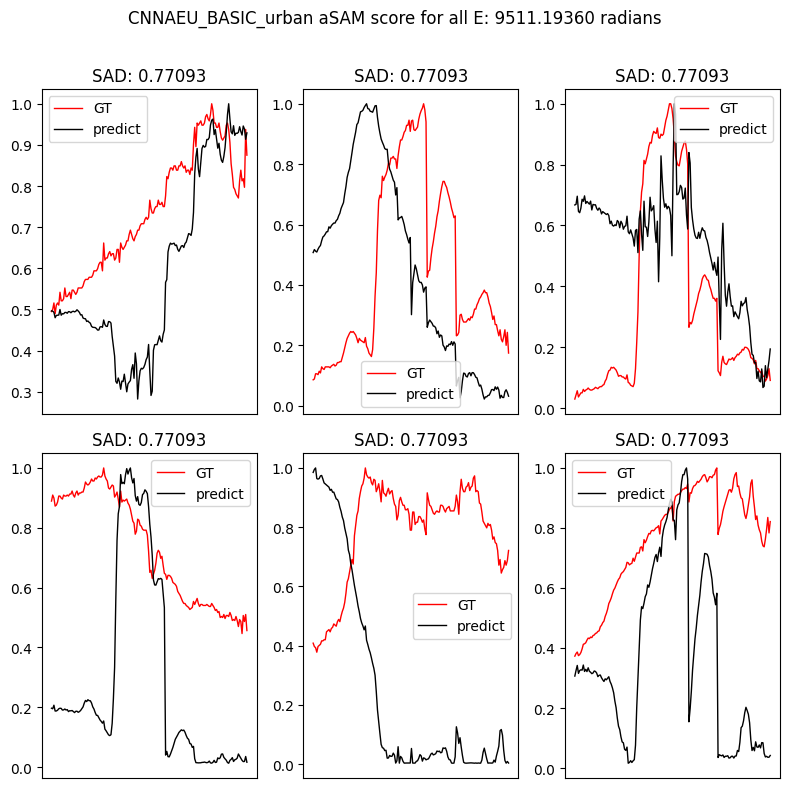

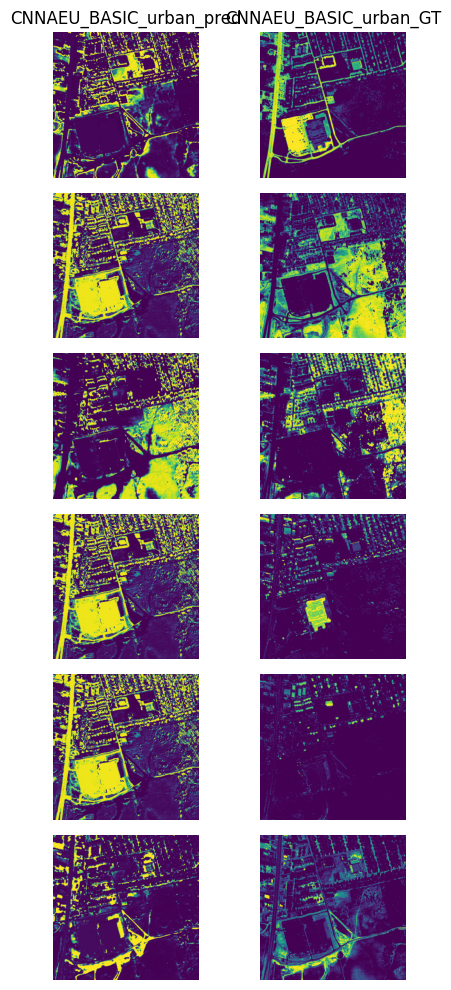

tensor([0.0759, 0.2478, 0.2067, 0.0423, 0.1534, 0.0569, 0.1305],
       device='cuda:0') tensor([0.7709, 0.7709, 0.7709, 0.7709, 0.7709, 0.7709], device='cuda:0')


/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/torch/utils/_device.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  return func(*args, **kwargs)


In [5]:
def run_one_xp(mses, sads, n, Y_init, B, c, N, H, loader, dataset, epochs, lr, dev):
    """
    Instanciating models
    """
    model_list = []

    # CNNAEU
    Y_loader, e_gt, a_gt = next(iter(loader))[0][0], next(iter(loader))[1][0], next(iter(loader))[2][0]
    cnnaeu = models.CNNAEU(B=B, c =c)
    cnnaeu = models.init_decoder_weights(cnnaeu, Y_loader, c, 11)
    model_list.append(cnnaeu)

    """
    Instanciating trainers
    """
    for i_model, model in enumerate(model_list):
        model_name = model.__class__.__name__

        print(f"Training {model_name}")

        e_hat, a_hat, train_losses = ssl.train(model, loader, patch_size=5, has_decoder=True, epochs=epochs, lr=lr, dev=dev)

        fig = plt.figure()
        plt.plot(train_losses)
        plt.close(fig)
        del e_hat, a_hat
        torch.cuda.empty_cache()

        model.load_state_dict(torch.load(f"/home/ids/edabier/HSU/SS-HSU_benchmark/models/{model_name}_Basic_{dataset}_lr_{lr}.pt")["model_state_dict"], strict=False)
        
        batch = next(iter(loader))
        Y, e_gt, a_gt = batch[0][0], batch[1][0], batch[2][0]
    
        A_init_disp = next(iter(loader))[2].to(torch.float32)
        E_init_disp = torch.ones(next(iter(loader))[1].size(),dtype=torch.float32)
        A_init = torch.ones_like(A_init_disp)
        E_init = torch.ones_like(E_init_disp)

        with torch.no_grad():
            e_hat, a_hat, y_hat = model.forward(Y)

        # if e_hat.dim() == 3:
        #     e_hat = e_hat.squeeze(0)

        # if a_hat.dim() == 3:
        #     a_hat = a_hat.squeeze(0)
        # print(e_hat.shape, e_gt.shape, a_hat.shape, a_gt.shape)
        
        a_hat, _ = utils.oneD_to_2d(a_hat[0])
        a_gt, _ = utils.oneD_to_2d(a_gt) 
        
        mse, sad = utils.compute_metrics_and_plot(e_hat, e_gt, a_hat, a_gt, name=f"{model_name}_BASIC_{dataset}", use_wandb=False)
        print(mse, sad)
        mses[i_model, n] = torch.tensor(mse[-1]).item()
        sads[i_model, n] = torch.tensor(sad[-1]).item()
        
        del e_hat, a_hat, y_hat
        del A_init, E_init
        del model
        torch.cuda.empty_cache()
    
    return mses, sads

datasets = ["urban"]

# shape (n_models, n_xp)
mses = torch.zeros(1, 1, device=dev)
sads = torch.zeros(1, 1, device=dev)
lr=0.003
epochs=2

for i_dataset, dataset in enumerate(datasets):

    print(f"####### {dataset} #######")
    data = io.loadmat(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}.mat")
    Y_init = torch.tensor(data["Y"], device=dev)
    Y_init = Y_init.to(torch.float32)
    E = torch.tensor(data["E"])
    B, c, N = E.shape[0], E.shape[1], Y_init.shape[1]

    Y_init, _ = utils.oneD_to_2d(Y_init)
    H, W = Y_init.shape[1], Y_init.shape[2]

    loader, _, _ = utils.create_dataloader(dataset, dev=dev, batch_size=1)

    mses, sads = run_one_xp(mses, sads, 0, Y_init, B, c, N, H, loader, dataset, epochs, lr, dev)
    
    mean_mses = torch.mean(mses, dim=1)
    std_mses = torch.std(mses, dim=1)
    mean_sads = torch.mean(sads, dim=1)
    std_sads = torch.std(sads, dim=1)